In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales: {collection.count_documents({}):,}")

total sales: 5,000


# Q9: Which products have the highest total quantity sold across all sales transactions?

In [17]:
#code for Query 9
from pprint import pprint

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "total_quantity_Sold": {"$sum": "$items.quantity"}
        }
    },
    {
        "$sort": {"total_quantity_Sold": -1}
    }
]

quentity = list(collection.aggregate(pipeline))
#pprint(quentity)

quentity_df = pd.DataFrame(quentity)
quentity_df.rename(columns={"_id": "Product Name", "total_quantity_Sold": "Total Quantity Sold"}, inplace=True) 

quentity_df

sai = quentity_df["Product Name"].tolist()
print(f"The Higest Quentity sold is:  {sai[0]}")

The Higest Quentity sold is:  binder


## Code for Visualization

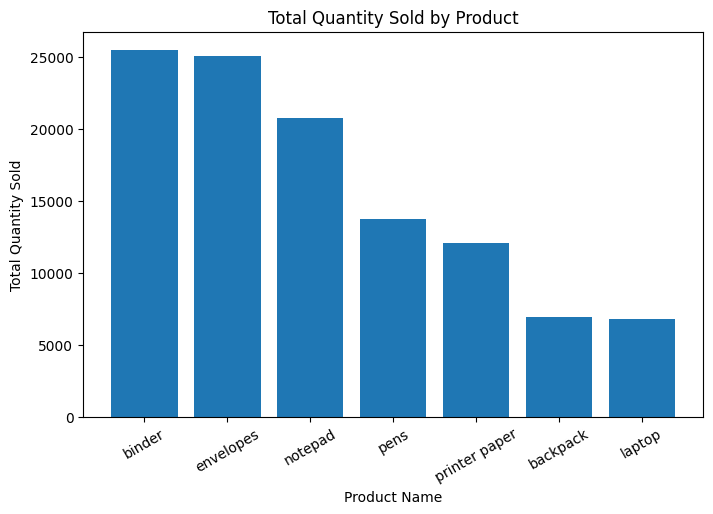

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    quentity_df["Product Name"],
    quentity_df["Total Quantity Sold"]
)

plt.title("Total Quantity Sold by Product")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=30)

plt.show()